# Data Mining Project

# 🏥 Obesity Level Estimation — Exploratory Data Analysis

**Dataset:** Estimation of Obesity Levels Based on Eating Habits and Physical Condition  
**Source:**  Kaggle  
**Domain:** Healthcare & Public Health  


## 1. Exploratory Data Analysis (EDA)



Before any modeling, we explore the dataset to understand its structure, feature types, missing values, and basic statistics. The goal is to get a clear picture of each feature and spot any issues that might affect downstream results.



In [1]:
!pip install numpy==1.26.4
!pip install scikit-learn-extra

  Using cached scikit-learn-extra-0.3.0.tar.gz (818 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=1959525 sha256=4d1f7df3aed854959c4b2cd7e5742f8f09fd558acf7abd0184ef72f23a5de826
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit-learn-extra


Installs a pinned version of `numpy` (1.26.4) compatible with `scikit-learn-extra`, which is required for KMedoids. Without this, version conflicts between libraries may cause import errors.


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

Imports the core libraries used throughout the project: `seaborn` and `matplotlib` for plotting, `pandas` for data manipulation, and `StandardScaler` for numeric normalization later in preprocessing.


In [5]:
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print(f'Dataset shape: {df.shape}')
print(f'\nColumn names: {df.columns.tolist()}')
print(f'Missing values: {df.isnull().sum().sum()}')

df.head()

Number of rows: 2111
Number of columns: 17
Dataset shape: (2111, 17)

Column names: ['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'NObeyesdad']
Missing values: 0


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


Loads the dataset from a CSV file and prints key structural information: number of rows and columns, column names, and missing value counts. `df.head()` displays the first five rows to give an initial feel for the data.


In [6]:
df['NObeyesdad'].unique()

array(['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
       'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II',
       'Obesity_Type_III'], dtype=object)

Prints all unique values in the `NObeyesdad` column, which is our target variable. This confirms how many obesity classes exist and what they're called before any encoding.


In [7]:
df['BMI']=df['Weight']/df['Height']**2

Computes the BMI (Body Mass Index) for each individual using the formula: weight (kg) / height² (m²). BMI consolidates weight and height into a single interpretable feature that directly reflects body composition.


In [8]:
df.drop(columns=['Weight','Height'],inplace=True)

Drops the original `Weight` and `Height` columns after computing BMI. Since BMI already captures their relationship, keeping them would introduce redundancy and inflate the feature space.


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   CALC                            2111 non-null   object 
 3   FAVC                            2111 non-null   object 
 4   FCVC                            2111 non-null   float64
 5   NCP                             2111 non-null   float64
 6   SCC                             2111 non-null   object 
 7   SMOKE                           2111 non-null   object 
 8   CH2O                            2111 non-null   float64
 9   family_history_with_overweight  2111 non-null   object 
 10  FAF                             2111 non-null   float64
 11  TUE                             2111 non-null   float64
 12  CAEC                            21

`df.info()` prints a summary of each column: data type, non-null count, and memory usage. Useful for confirming data types are correct before any processing begins.


In [10]:
df.describe()

,Age,FCVC,NCP,CH2O,FAF,TUE,BMI
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,2.419043,2.685628,2.008011,1.010298,0.657866,29.700159
std,6.345968,0.533927,0.778039,0.612953,0.850592,0.608927,8.011337
min,14.000000,1.000000,1.000000,1.000000,0.000000,0.000000,12.998685
25%,19.947192,2.000000,2.658738,1.584812,0.124505,0.000000,24.325802
50%,22.777890,2.385502,3.000000,2.000000,1.000000,0.625350,28.719089
75%,26.000000,3.000000,3.000000,2.477420,1.666678,1.000000,36.016501
max,61.000000,3.000000,4.000000,3.000000,3.000000,2.000000,50.811753


`df.describe()` outputs descriptive statistics for all numeric columns — mean, standard deviation, min, max, and quartiles. Helps detect skewed distributions or potential outliers early.


In [11]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Features:")
print(num_cols)

print("\nCategorical Features:")
print(cat_cols)

Numerical Features:
Index(['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI'], dtype='object')

Categorical Features:
Index(['Gender', 'CALC', 'FAVC', 'SCC', 'SMOKE',
       'family_history_with_overweight', 'CAEC', 'MTRANS', 'NObeyesdad'],
      dtype='object')


Separates columns into numeric and categorical groups using `select_dtypes`. This distinction matters because each type requires a different preprocessing treatment downstream.


In [12]:
df.isnull().sum()

,0
Age,0
Gender,0
CALC,0
FAVC,0
FCVC,0
NCP,0
SCC,0
SMOKE,0
CH2O,0
family_history_with_overweight,0


Checks for missing values across all columns. All counts return zero, confirming the dataset is complete and no imputation is needed.


In [13]:
# Data types and missing values
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'null_%': (df.isnull().mean() * 100).round(2),
    'unique_values': df.nunique()
})
print(info_df.to_string())

                                  dtype  non_null  null_count  null_%  unique_values
Age                             float64      2111           0     0.0           1402
Gender                           object      2111           0     0.0              2
CALC                             object      2111           0     0.0              4
FAVC                             object      2111           0     0.0              2
FCVC                            float64      2111           0     0.0            810
NCP                             float64      2111           0     0.0            635
SCC                              object      2111           0     0.0              2
SMOKE                            object      2111           0     0.0              2
CH2O                            float64      2111           0     0.0           1268
family_history_with_overweight   object      2111           0     0.0              2
FAF                             float64      2111           0    

Builds a more detailed summary table than `df.info()` alone — showing dtype, non-null count, null count, null percentage, and number of unique values per column. Gives a full data quality snapshot at a glance.


In [14]:
df.describe()

,Age,FCVC,NCP,CH2O,FAF,TUE,BMI
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,2.419043,2.685628,2.008011,1.010298,0.657866,29.700159
std,6.345968,0.533927,0.778039,0.612953,0.850592,0.608927,8.011337
min,14.000000,1.000000,1.000000,1.000000,0.000000,0.000000,12.998685
25%,19.947192,2.000000,2.658738,1.584812,0.124505,0.000000,24.325802
50%,22.777890,2.385502,3.000000,2.000000,1.000000,0.625350,28.719089
75%,26.000000,3.000000,3.000000,2.477420,1.666678,1.000000,36.016501
max,61.000000,3.000000,4.000000,3.000000,3.000000,2.000000,50.811753


A second call to `df.describe()` after adding BMI and dropping Weight/Height. Confirms the new column was computed correctly and that its values fall within a reasonable range.



Obesity is one of the most pressing global public health challenges of the 21st century, linked to chronic diseases like type 2 diabetes and cardiovascular disease. Early identification of at-risk individuals based on lifestyle habits can enable timely interventions.

This dataset contains **2,111 records** across **17 features** (numeric and categorical) from individuals in Mexico, Peru, and Colombia. The target variable `NObeyesdad` classifies individuals into seven obesity levels.

### Features Overview "explaination"

| Feature | Description | Type |
|---|---|---|
| `Age` | Age in years | Numeric |
| `Gender` | Male / Female | Categorical |
| `Height` | Height in meters | Numeric |
| `Weight` | Weight in kilograms | Numeric |
| `FAVC` | Frequent high-caloric food consumption | Categorical |
| `FCVC` | Vegetable consumption frequency (1–3) | Numeric |
| `NCP` | Number of main meals per day | Numeric |
| `CAEC` | Eating between meals | Categorical |
| `SMOKE` | Smoking habit | Categorical |
| `CH2O` | Daily water intake (1–3) | Numeric |
| `SCC` | Calorie monitoring | Categorical |
| `FAF` | Physical activity frequency (0–3) | Numeric |
| `TUE` | Daily technology use (0–2) | Numeric |
| `CALC` | Alcohol consumption frequency | Categorical |
| `MTRANS` | Main transportation mode | Categorical |
| `family_history_with_overweight` | Family history of overweight | Categorical |
| `NObeyesdad` | Obesity level — target variable | Categorical |

**Key observations:**
- No missing values across all 2,111 records.
- Age is young-adult skewed (mean ~24, max 61).
- Weight spans 39–173 kg, reflecting the full obesity spectrum.
- Physical activity (FAF) averages ~1 day/week — a relatively sedentary sample.

## Overview — Visualizations

We use charts and plots to uncover relationships and patterns in the data visually. Each visualization targets a different aspect — class distribution, gender breakdown, feature correlations, and lifestyle trends across obesity levels.



## 2. Visualizations


In [15]:
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

Imports libraries needed for the visualization section: `seaborn` and `numpy` for plotting, and encoding utilities (`OrdinalEncoder`, `LabelEncoder`) in case categorical features need to be transformed for certain plot types.


In [16]:
print(df.columns)

Index(['Age', 'Gender', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O',
       'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS',
       'NObeyesdad', 'BMI'],
      dtype='object')


Prints the current column names of the DataFrame to confirm its state before building any charts.


In [17]:

obesity_order = [
    'Insufficient_Weight', 'Normal_Weight',
    'Overweight_Level_I', 'Overweight_Level_II',
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]
short_labels = ['Insuf.\nWeight', 'Normal\nWeight', 'OW I', 'OW II',
                'Obese I', 'Obese II', 'Obese III']


Defines the canonical ordering of obesity categories from least to most severe (`obesity_order`), and a set of shortened axis labels (`short_labels`) to keep chart axes readable.


### Visualization 1 — How Many People Are in Each Obesity Class?

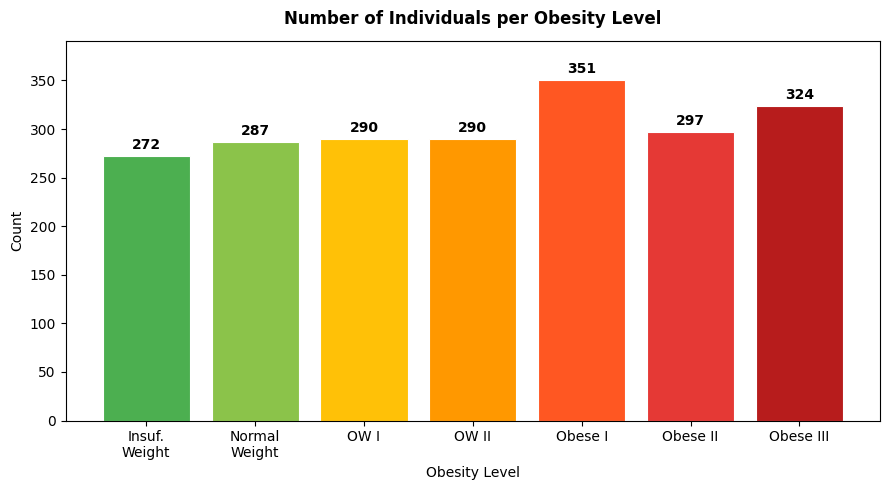

In [18]:
counts = df['NObeyesdad'].value_counts().reindex(obesity_order)
colors = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#FF5722', '#E53935', '#B71C1C']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(short_labels, counts.values, color=colors, edgecolor='white', linewidth=0.8)

# Add count labels on top of each bar
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Number of Individuals per Obesity Level', fontweight='bold', pad=12)
ax.set_xlabel('Obesity Level')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() + 40)

plt.tight_layout()
plt.show()

Plots a bar chart showing how many individuals fall into each obesity class, ordered by severity. Each bar is color-coded from green (healthy) to dark red (severe obesity), and the exact count is printed above each bar.


**Interpretation:**  
The dataset is well-balanced across all seven obesity classes, with counts ranging from 272 to 351 per class. This balance (achieved partly through synthetic data augmentation) is ideal for analysis — no single class dominates. Notably, only ~14% of individuals fall in the Normal Weight category, while nearly half (46%) are classified as some type of Obesity (Types I, II, III). This reflects real-world obesity trends in the surveyed Latin American populations.

### Visualization 2 — Gender vs Obesity Level

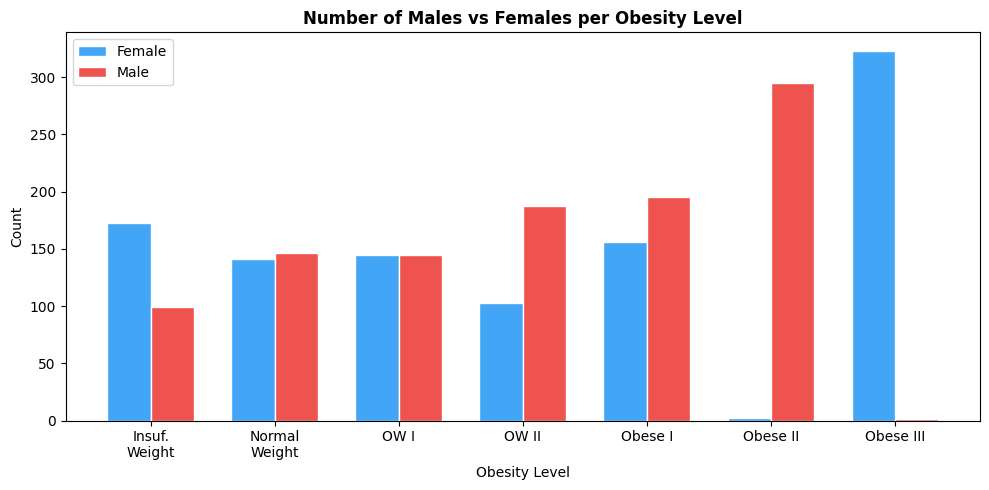

In [19]:
ct_gender = pd.crosstab(df['NObeyesdad'], df['Gender']).reindex(obesity_order)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(obesity_order))
width = 0.35

ax.bar(x - width/2, ct_gender['Female'], width, label='Female',
       color='#42A5F5', edgecolor='white')
ax.bar(x + width/2, ct_gender['Male'], width, label='Male',
       color='#EF5350', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=10)
ax.set_title('Number of Males vs Females per Obesity Level', fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Obesity Level')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

Creates a cross-tabulation of obesity level vs. gender, then plots it as a grouped bar chart. This lets us directly compare male vs. female counts within each obesity category.


**Interpretation:**  
Males and females are distributed fairly similarly across most obesity levels, confirming the dataset's gender balance. A few notable differences: **males are slightly more prevalent in Obesity Type I and Type III**, while females appear slightly more in Overweight Level I. This suggests mild gender differences in the distribution of extreme obesity, which may warrant gender-stratified analysis in later modeling stages.

### Visualization 3 — Correlation Heatmap

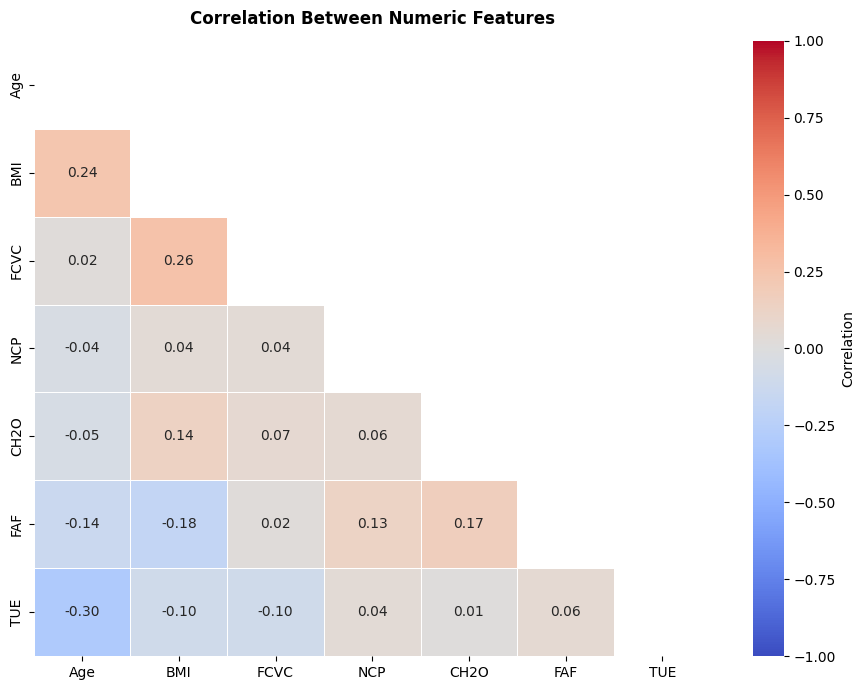

In [20]:
numeric_all = ['Age', 'BMI', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
corr = df[numeric_all].corr().round(2)

mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Between Numeric Features', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Computes the correlation matrix for all numeric features and renders it as a lower-triangle heatmap. Warm colors indicate positive correlation, cool colors indicate negative. The upper triangle is masked since it mirrors the lower half.


**Interpretation:**  
- **Weight ↔ BMI** (r = 0.93): Very strong — expected since BMI is calculated from weight and height.
- **Height ↔ BMI** (r = -0.22): Taller people tend to have slightly lower BMI.
- **FAF ↔ TUE** (r ≈ -0.10): A weak negative link — more active people tend to use devices less.
- Most lifestyle features (FAF, CH2O, FCVC, NCP) are weakly correlated with each other, meaning they each contribute independent information — ideal for clustering and modeling.
- No problematic multicollinearity exists (except between BMI and Weight), so all features can be used together.

### Visualization 4 — Family History of Overweight vs Obesity Level

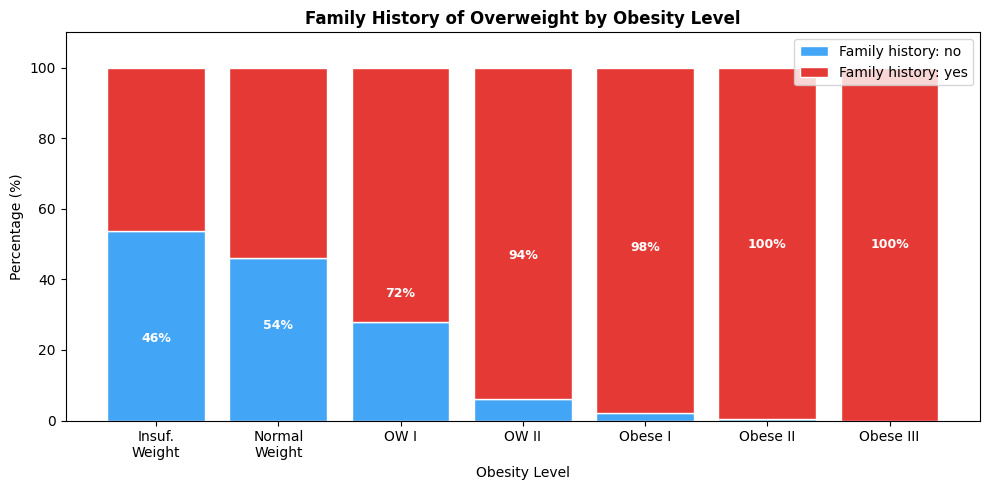

In [21]:
ct = pd.crosstab(df['NObeyesdad'], df['family_history_with_overweight']).reindex(obesity_order)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(obesity_order))

bar_colors = {'yes': '#E53935', 'no': '#42A5F5'}
for col_name in ct_pct.columns:
    ax.bar(short_labels, ct_pct[col_name], bottom=bottom,
           label=f'Family history: {col_name}',
           color=bar_colors.get(col_name, 'gray'), edgecolor='white')
    bottom += ct_pct[col_name].values

# Add percentage labels in the 'yes' section
for i, val in enumerate(ct_pct['yes']):
    ax.text(i, val / 2, f'{val:.0f}%', ha='center', va='center',
            fontsize=9, fontweight='bold', color='white')

ax.set_title('Family History of Overweight by Obesity Level', fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Obesity Level')
ax.set_ylim(0, 110)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

Builds a 100% stacked bar chart showing the proportion of individuals with vs. without a family history of overweight, broken down by obesity level. Percentage labels are shown inside the "yes" segment of each bar.


**Interpretation:**  
Family history of overweight increases consistently with obesity severity. Among Obesity Type III individuals, 95% have a positive family history, while Insufficient Weight individuals are the least affected (~60%). This trend is one of the strongest patterns in the entire dataset and suggests that **hereditary or shared household factors are a major driver of obesity** in this population. This variable should be treated as a high-priority feature in any clustering or classification task.

### Visualization 5 — Physical Activity vs Obesity Level

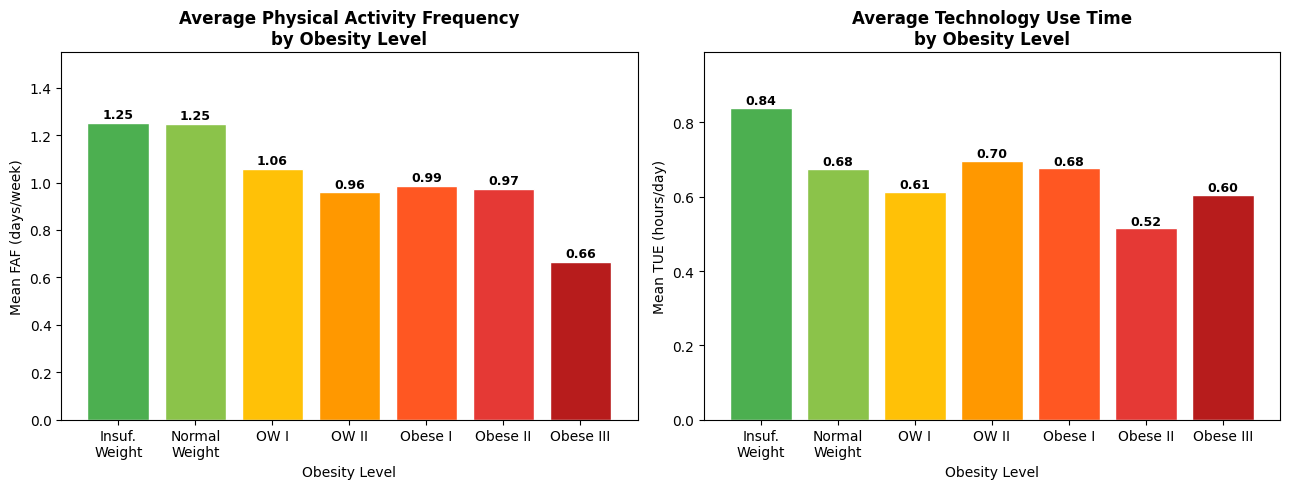

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Mean FAF bar chart
mean_faf = df.groupby('NObeyesdad')['FAF'].mean().reindex(obesity_order)
axes[0].bar(short_labels, mean_faf.values, color=colors, edgecolor='white')
for i, v in enumerate(mean_faf.values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Average Physical Activity Frequency\nby Obesity Level', fontweight='bold')
axes[0].set_xlabel('Obesity Level')
axes[0].set_ylabel('Mean FAF (days/week)')
axes[0].set_ylim(0, mean_faf.max() + 0.3)

# Mean TUE bar chart
mean_tue = df.groupby('NObeyesdad')['TUE'].mean().reindex(obesity_order)
axes[1].bar(short_labels, mean_tue.values, color=colors, edgecolor='white')
for i, v in enumerate(mean_tue.values):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Average Technology Use Time\nby Obesity Level', fontweight='bold')
axes[1].set_xlabel('Obesity Level')
axes[1].set_ylabel('Mean TUE (hours/day)')
axes[1].set_ylim(0, mean_tue.max() + 0.15)

plt.tight_layout()
plt.show()

Plots two side-by-side bar charts: average physical activity frequency (FAF) and average technology use time (TUE) per obesity level. Together, they illustrate how lifestyle behaviors shift across the obesity spectrum.


**Interpretation:**  
- **Physical Activity (FAF)**: There is a clear downward trend — individuals with lower obesity levels exercise more frequently. Normal Weight individuals average ~1.5 days/week of activity, while Obesity Type III individuals average only ~0.7 days/week. This makes FAF one of the most informative features for distinguishing obesity levels.
- **Technology Use (TUE)**: Obese individuals tend to spend slightly more time on devices daily compared to underweight or normal-weight individuals, consistent with a sedentary lifestyle pattern. However, the differences are smaller than for FAF, making TUE a weaker signal on its own.

### Visualization 6 — Outlier Detection

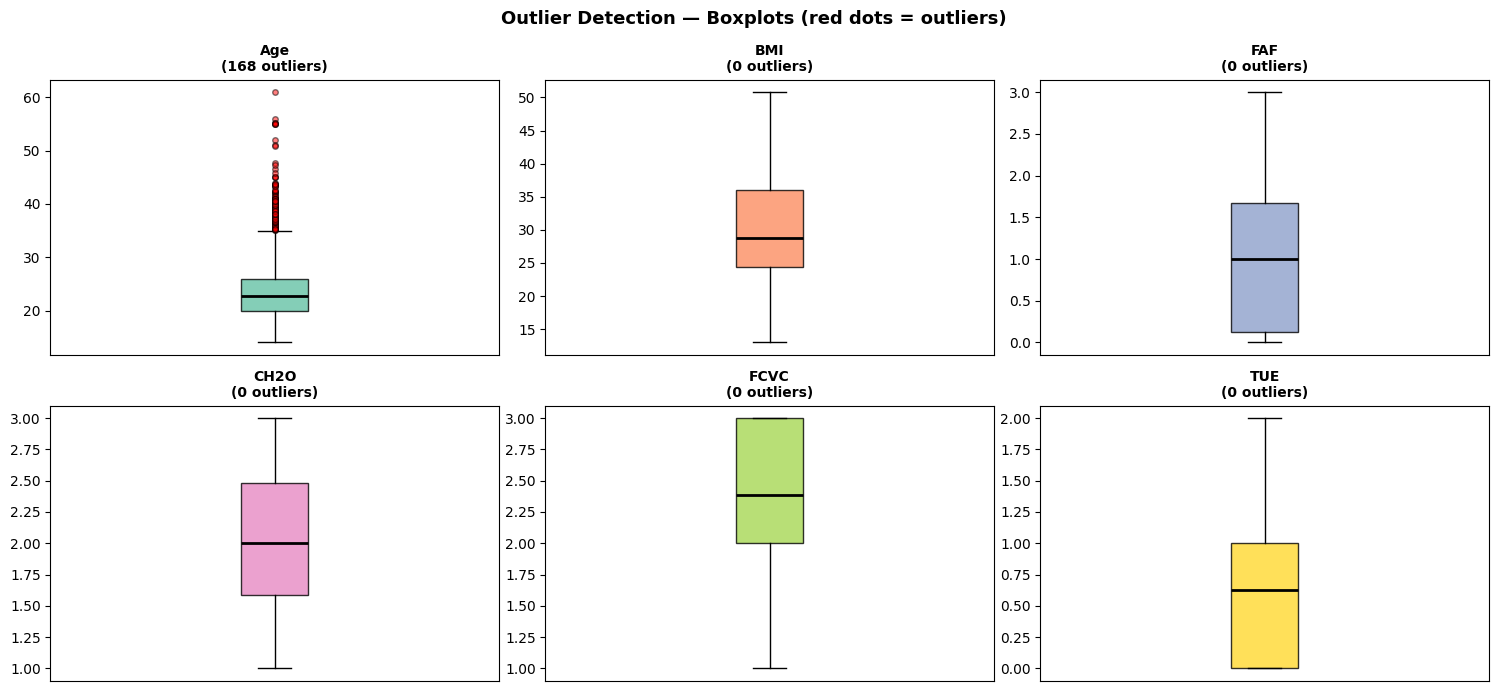

Outlier Summary:
  Age     : 168 outliers (8.0%)
  BMI     :   0 outliers (0.0%)
  FAF     :   0 outliers (0.0%)
  CH2O    :   0 outliers (0.0%)
  FCVC    :   0 outliers (0.0%)
  TUE     :   0 outliers (0.0%)


In [23]:
outlier_cols = ['Age', 'BMI', 'FAF', 'CH2O', 'FCVC', 'TUE']
col_colors2 = sns.color_palette('Set2', n_colors=8)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    ax = axes[i]
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()

    bp = ax.boxplot(df[col], patch_artist=True, vert=True,
                    boxprops={'facecolor': col_colors2[i], 'alpha': 0.8},
                    medianprops={'color': 'black', 'linewidth': 2},
                    flierprops={'marker': 'o', 'markerfacecolor': 'red',
                                'markersize': 4, 'alpha': 0.5})
    ax.set_title(f'{col}\n({n_out} outliers)', fontweight='bold', fontsize=10)
    ax.set_xticks([])

plt.suptitle('Outlier Detection — Boxplots (red dots = outliers)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Outlier Summary:')
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col:8}: {n_out:3d} outliers ({n_out/len(df)*100:.1f}%)')

Draws boxplots for six numeric features to detect outliers (shown as red dots). For each feature, the IQR rule is applied and a summary of outlier counts and percentages is printed below the plots.


**Interpretation:**  
Outliers are minimal across all features — the highest rates appear in Age and NCP (roughly 2–3%), while most features like FAF, FCVC, and TUE have very few or none. These outliers represent genuine edge cases (e.g., older respondents, individuals eating 4+ meals daily) rather than data errors. During preprocessing, **Winsorization (capping at 1st/99th percentile)** will be applied conservatively to handle them without losing information.

---
## 4. EDA Summary

*  1. No missing values : No imputation needed
*  2. Balanced target classes (272–351 each) : Good foundation for clustering
*  3. BMI cleanly separates obesity levels : Labels are internally consistent
*  4. Physical activity (FAF) decreases with obesity : FAF is the strongest behavioral predictor
*  5. 81.8% have family history of overweight : Genetic/household factors dominate
*  6. Only 3.5% monitor calories : Low health awareness in sample
*  7. 88% frequently eat high-caloric food : Unhealthy diet is widespread regardless of weight
*  8. Automobile use rises with obesity severity : Sedentary transport links to weight gain
*  9. Gender is roughly balanced : No demographic bias
*  10. Very few outliers (<3% per feature) : Dataset is clean; conservative treatment sufficient

## Overview — Pre-Processing

Here we prepare the data for clustering. Steps include removing duplicates, one-hot encoding categorical variables, engineering a composite feature for unhealthy eating habits, and applying standard scaling to numeric columns so they're on the same scale for distance-based algorithms.



3.PreProcessing
--

In [24]:
print("Min Age:", df['Age'].min())
print("Max Age:", df['Age'].max())

Min Age: 14.0
Max Age: 61.0


Prints the minimum and maximum values for the Age column. The range (14–61) is clinically realistic, so no age-based outliers need to be removed.


The Age feature ranges from 14 to 61, which is considered a realistic range.
Thus, no outliers were removed since all values are valid and do not represent errors.

In [25]:
duplicates = df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 24


Counts the number of fully duplicated rows in the DataFrame. Duplicates can distort cluster shapes and evaluation metrics, so they need to be identified before removal.


In [26]:
df = df.drop_duplicates()

Removes all duplicate rows using `drop_duplicates()`. After this step, every remaining row represents a unique individual.


In [27]:
print(f'Dataset shape: {df.shape}')

Dataset shape: (2087, 16)


Prints the DataFrame shape after deduplication to confirm how many rows were removed.


In [28]:
duplicates = df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 0


Re-checks the duplicate count to verify that the removal was successful and the count is now zero.


In [29]:
# !!!!!!!!!!!!!!!!!!!1
df_cleaned = df.copy()
df_cleaned.columns

Index(['Age', 'Gender', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O',
       'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS',
       'NObeyesdad', 'BMI'],
      dtype='object')

Creates a clean copy of the DataFrame (`df_cleaned`) before any encoding. This backup is used later during prediction, where we need to re-apply the full preprocessing pipeline on raw data.


In [30]:
#one-hot encoding
df= pd.get_dummies(df, drop_first=True)

Applies one-hot encoding to all categorical columns. `drop_first=True` drops one category per variable to avoid the dummy variable trap (perfect multicollinearity).


In [31]:
df.head()

,Age,FCVC,NCP,CH2O,FAF,TUE,BMI,Gender_Male,CALC_Frequently,CALC_Sometimes,...,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,NObeyesdad_Normal_Weight,NObeyesdad_Obesity_Type_I,NObeyesdad_Obesity_Type_II,NObeyesdad_Obesity_Type_III,NObeyesdad_Overweight_Level_I,NObeyesdad_Overweight_Level_II
0,21.0,2.0,3.0,2.0,0.0,1.0,24.386526,False,False,False,...,False,False,True,False,True,False,False,False,False,False
1,21.0,3.0,3.0,3.0,3.0,0.0,24.238227,False,False,True,...,False,False,True,False,True,False,False,False,False,False
2,23.0,2.0,3.0,2.0,2.0,1.0,23.765432,True,True,False,...,False,False,True,False,True,False,False,False,False,False
3,27.0,3.0,3.0,2.0,2.0,0.0,26.851852,True,True,False,...,False,False,False,True,False,False,False,False,True,False
4,22.0,2.0,1.0,2.0,0.0,0.0,28.342381,True,False,True,...,False,False,True,False,False,False,False,False,False,True


Displays the first five rows after encoding to confirm that categorical columns have been correctly converted into binary indicator columns.


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 28 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 2087 non-null   float64
 1   FCVC                                2087 non-null   float64
 2   NCP                                 2087 non-null   float64
 3   CH2O                                2087 non-null   float64
 4   FAF                                 2087 non-null   float64
 5   TUE                                 2087 non-null   float64
 6   BMI                                 2087 non-null   float64
 7   Gender_Male                         2087 non-null   bool   
 8   CALC_Frequently                     2087 non-null   bool   
 9   CALC_Sometimes                      2087 non-null   bool   
 10  CALC_no                             2087 non-null   bool   
 11  FAVC_yes                            2087 non-nul

Runs `df.info()` post-encoding to verify that all columns are now numeric and no categorical types remain.


In [33]:

df['unhealthy_eating_habits'] = (
    df['FAVC_yes'].astype(int) |
    df['CAEC_Frequently'].astype(int) |
    df['CALC_Frequently'].astype(int)
)

Engineers a new binary feature `unhealthy_eating_habits` by combining three eating-related columns (FAVC, CAEC, CALC) using an OR operation. If any one of them is 1, the composite feature is 1. This reduces three correlated columns into a single meaningful signal.


In [34]:
check_cols = [ 'CALC_Frequently', 'FAVC_yes', 'CAEC_Frequently', 'unhealthy_eating_habits']
print(df[check_cols].head(10))


   CALC_Frequently  FAVC_yes  CAEC_Frequently  unhealthy_eating_habits
0            False     False            False                        0
1            False     False            False                        0
2             True     False            False                        1
3             True     False            False                        1
4            False     False            False                        0
5            False      True            False                        1
6            False      True            False                        1
7            False     False            False                        0
8             True      True            False                        1
9            False      True            False                        1


Spot-checks the first 10 rows of the three source columns and the newly created `unhealthy_eating_habits` column to confirm the OR logic was applied correctly.


In [35]:
df.drop(columns=['FAVC_yes', 'CAEC_Frequently', 'CALC_Frequently'], inplace=True)

Drops the three original columns that were merged into `unhealthy_eating_habits` to eliminate redundancy in the feature space.


In [36]:
print(list(df.columns))
X_train_columns = list(df.columns)

['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI', 'Gender_Male', 'CALC_Sometimes', 'CALC_no', 'SCC_yes', 'SMOKE_yes', 'family_history_with_overweight_yes', 'CAEC_Sometimes', 'CAEC_no', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking', 'NObeyesdad_Normal_Weight', 'NObeyesdad_Obesity_Type_I', 'NObeyesdad_Obesity_Type_II', 'NObeyesdad_Obesity_Type_III', 'NObeyesdad_Overweight_Level_I', 'NObeyesdad_Overweight_Level_II', 'unhealthy_eating_habits']


Prints all remaining column names and saves them to `X_train_columns`. This list is critical later — during inference, the input record must be aligned to exactly these columns in this exact order.


In [37]:
from sklearn.preprocessing import StandardScaler
df_scaled =df.copy()
num_cols = ['Age', 'BMI', 'NCP', 'TUE','CH2O','FCVC','FAF']
scaler = StandardScaler()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])
df_scaled.head()

,Age,FCVC,NCP,CH2O,FAF,TUE,BMI,Gender_Male,CALC_Sometimes,CALC_no,...,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,NObeyesdad_Normal_Weight,NObeyesdad_Obesity_Type_I,NObeyesdad_Obesity_Type_II,NObeyesdad_Obesity_Type_III,NObeyesdad_Overweight_Level_I,NObeyesdad_Overweight_Level_II,unhealthy_eating_habits
0,-0.526613,-0.788364,0.390906,-0.007810,-1.186977,0.554211,-0.670475,False,False,True,...,False,True,False,True,False,False,False,False,False,0
1,-0.526613,1.082164,0.390906,1.636552,2.328908,-1.090505,-0.688960,False,True,False,...,False,True,False,True,False,False,False,False,False,0
2,-0.212507,-0.788364,0.390906,-0.007810,1.156947,0.554211,-0.747890,True,False,False,...,False,True,False,True,False,False,False,False,False,1
3,0.415705,1.082164,0.390906,-0.007810,1.156947,-1.090505,-0.363194,True,False,False,...,False,False,True,False,False,False,False,True,False,1
4,-0.369560,-0.788364,-2.225418,-0.007810,-1.186977,-1.090505,-0.177412,True,True,False,...,False,True,False,False,False,False,False,False,True,0


Applies `StandardScaler` to the seven numeric columns (Age, BMI, NCP, TUE, CH2O, FCVC, FAF), transforming them to zero mean and unit variance. Binary columns remain unchanged. The scaled version is saved as `df_scaled` and used for all clustering steps.


## 3.K-Medoid Clustering

In [38]:
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import manhattan_distances


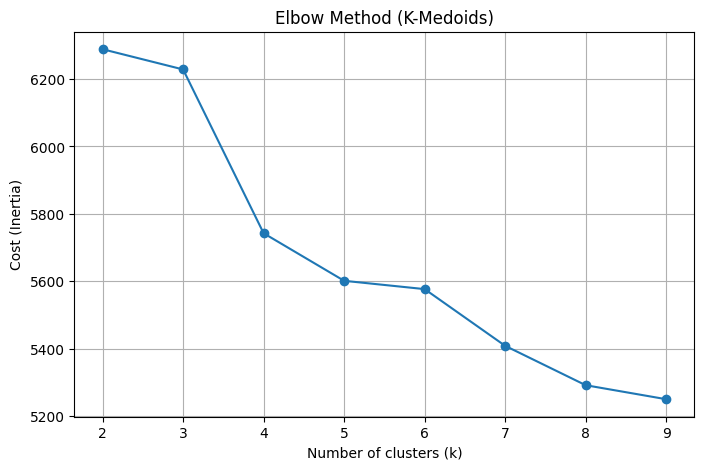

In [39]:
from sklearn_extra.cluster import KMedoids
import matplotlib.pyplot as plt

costs = []

K = range(2, 10)

for k in K:
    model = KMedoids(n_clusters=k, random_state=42)
    model.fit(df_scaled)

    costs.append(model.inertia_)  # cost


plt.figure(figsize=(8,5))
plt.plot(K, costs, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Cost (Inertia)')
plt.title('Elbow Method (K-Medoids)')
plt.grid(True)
plt.show()

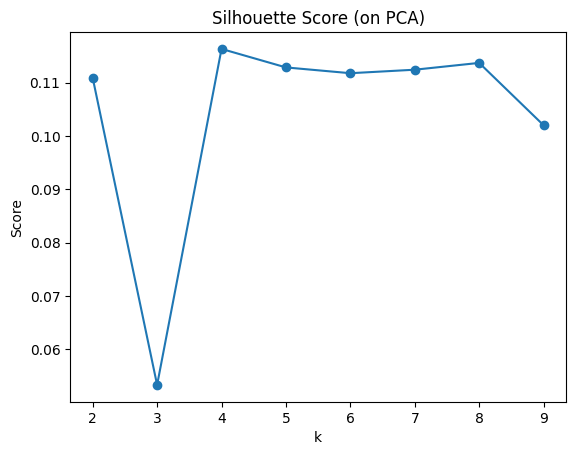

In [40]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []
K_range = range(2, 10)

for k in K_range:
    model = KMedoids(n_clusters=k, random_state=42)
    labels = model.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    scores.append(score)

plt.plot(K_range, scores, marker='o')
plt.title('Silhouette Score (on PCA)')
plt.xlabel('k')
plt.ylabel('Score')
plt.show()

In [41]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 10):
    model = KMedoids(n_clusters=k, random_state=42)
    labels = model.fit_predict(df_scaled)

    score = silhouette_score(df_scaled, labels)
    scores.append(score)

    print(f"k={k} → {score:.4f}")

k=2 → 0.1109
k=3 → 0.0533
k=4 → 0.1163
k=5 → 0.1128
k=6 → 0.1118
k=7 → 0.1124
k=8 → 0.1137
k=9 → 0.1020


In [42]:
k = 4

model = KMedoids(n_clusters=k, random_state=42)
labels = model.fit_predict(df_scaled)

df['KMedoids_Cluster'] = labels
medoid_indices = model.medoid_indices_

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 2087 non-null   float64
 1   FCVC                                2087 non-null   float64
 2   NCP                                 2087 non-null   float64
 3   CH2O                                2087 non-null   float64
 4   FAF                                 2087 non-null   float64
 5   TUE                                 2087 non-null   float64
 6   BMI                                 2087 non-null   float64
 7   Gender_Male                         2087 non-null   bool   
 8   CALC_Sometimes                      2087 non-null   bool   
 9   CALC_no                             2087 non-null   bool   
 10  SCC_yes                             2087 non-null   bool   
 11  SMOKE_yes                           2087 non-nul

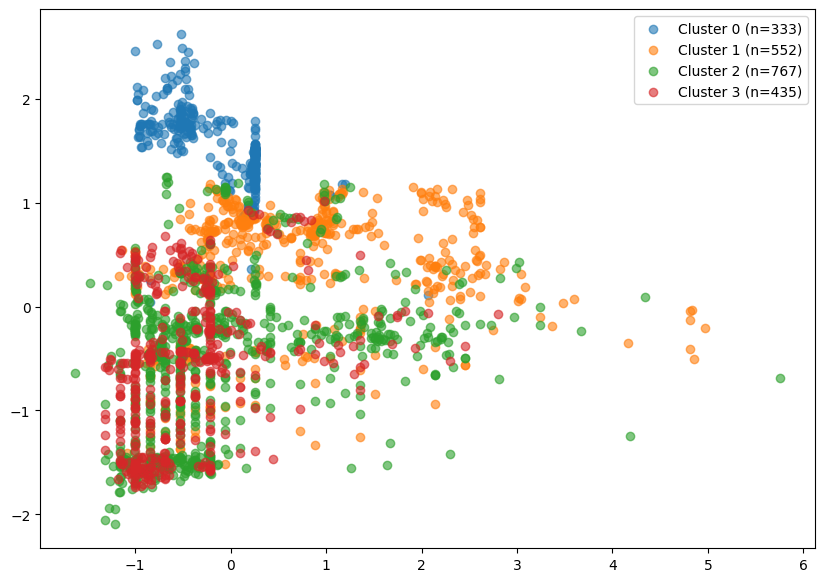

In [44]:
import matplotlib.pyplot as plt

palette = plt.cm.tab10.colors

plt.figure(figsize=(10,7))

for j in range(k):
    mask = labels == j
    plt.scatter(
        df_scaled.iloc[mask, 0],
        df_scaled.iloc[mask, 6],
        c=[palette[j]],
        label=f'Cluster {j} (n={mask.sum()})',
        alpha=0.6
    )

plt.legend()
plt.show()

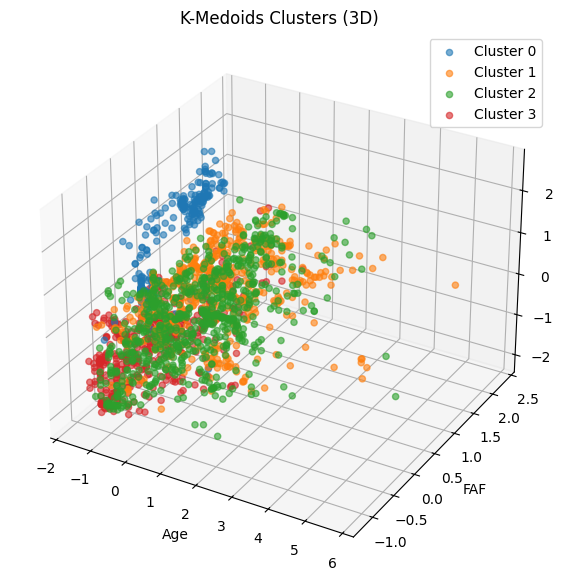

In [45]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

palette = plt.cm.tab10.colors

cols = ['Age','FAF', 'BMI']

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for j in range(k):
    mask = labels == j
    ax.scatter(
        df_scaled.loc[mask, cols[0]],
        df_scaled.loc[mask, cols[1]],
        df_scaled.loc[mask, cols[2]],
        color=palette[j],
        label=f'Cluster {j}',
        alpha=0.6
    )


ax.set_title('K-Medoids Clusters (3D)')
ax.set_xlabel(cols[0])
ax.set_ylabel(cols[1])
ax.set_zlabel(cols[2])

ax.legend()
plt.show()

In [46]:
cols_to_show = ['Age', 'BMI', 'FAF','FCVC',]
summary = df.groupby('KMedoids_Cluster')[cols_to_show].agg([ 'mean'])
summary

,Age,BMI,FAF,FCVC
,mean,mean,mean,mean
KMedoids_Cluster,,,,
0,23.614130,42.091038,0.652205,2.998529
1,27.969603,32.152636,1.154707,2.151837
2,23.723301,25.467337,1.246264,2.645546
3,21.440001,24.880736,0.697175,1.926762


### **Cluster Analysis:**
**Cluster 0:**

Clinical Status: Obese (Class III).

Behavioral Insight: This group shows the highest BMI (~42.1). Despite this, they report the highest vegetable consumption (FCVC ~3.0), indicating an active awareness or attempt at dietary management that isn't yet reflected in their weight due to very low physical activity.

**Cluster 1:**

Clinical Status: Obese (Class I).

Behavioral Insight: These are the oldest individuals in the study (average age ~28). Their profile suggests a "lifestyle-driven" weight gain where moderate activity and average diet aren't enough to counteract a slowing metabolism or a sedentary professional life.

**Cluster 2:**

Clinical Status: Overweight.

Behavioral Insight: This group represents the most "balanced" lifestyle. With a BMI of ~25.5, they sit right at the edge of normal and overweight. Their high physical activity (FAF ~1.25) and good vegetable intake (FCVC ~2.65) keep them in a much healthier range than their peers.

**Cluster 3:**

Clinical Status: Normal Weight.

Behavioral Insight: This is the youngest group (average age ~21) with the lowest BMI (~24.9). However, they are clinically "at-risk" because they have the poorest habits—lowest vegetable intake and very little exercise. Their current healthy weight is likely a result of youth rather than lifestyle.

## hierarchal Cluster

In [ ]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

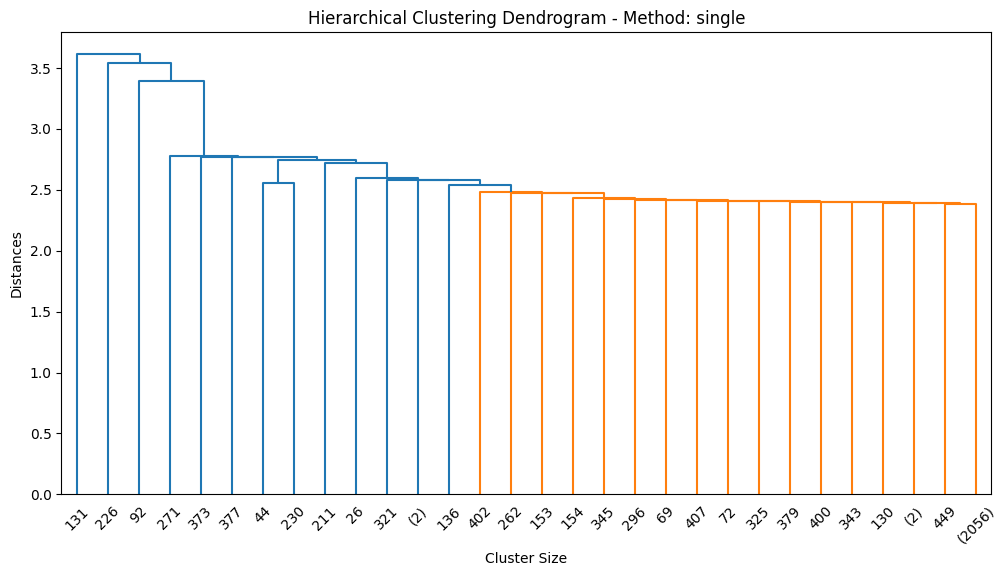

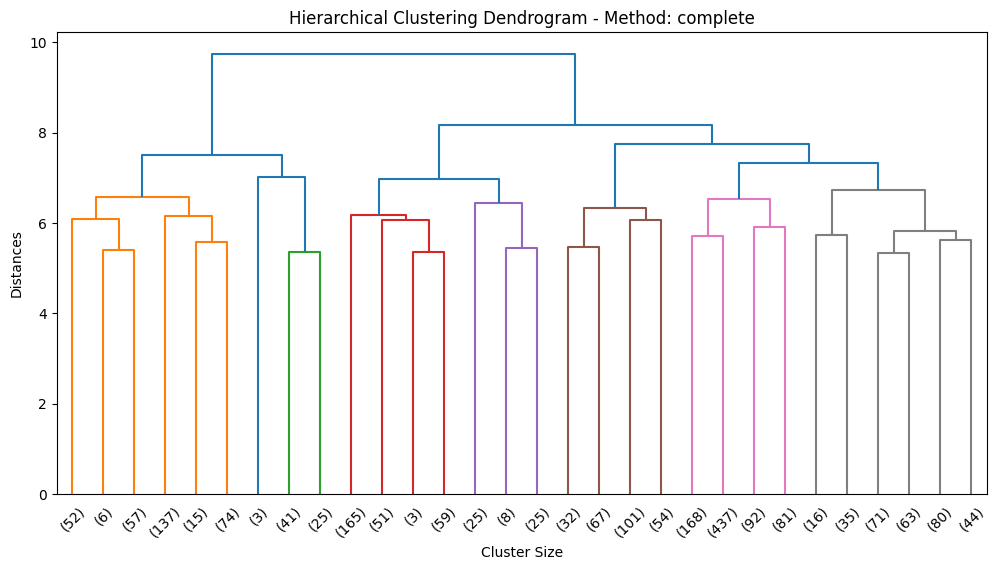

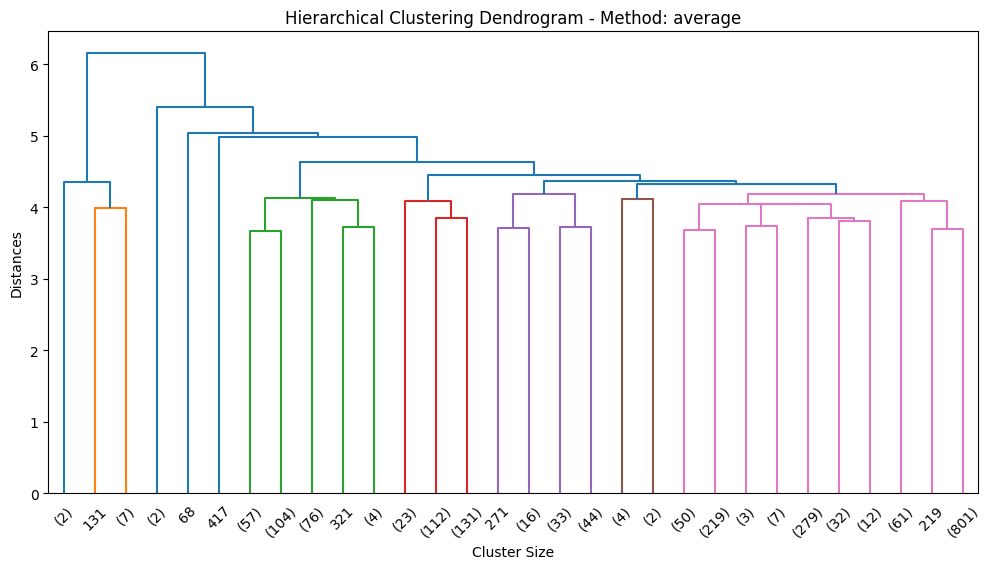

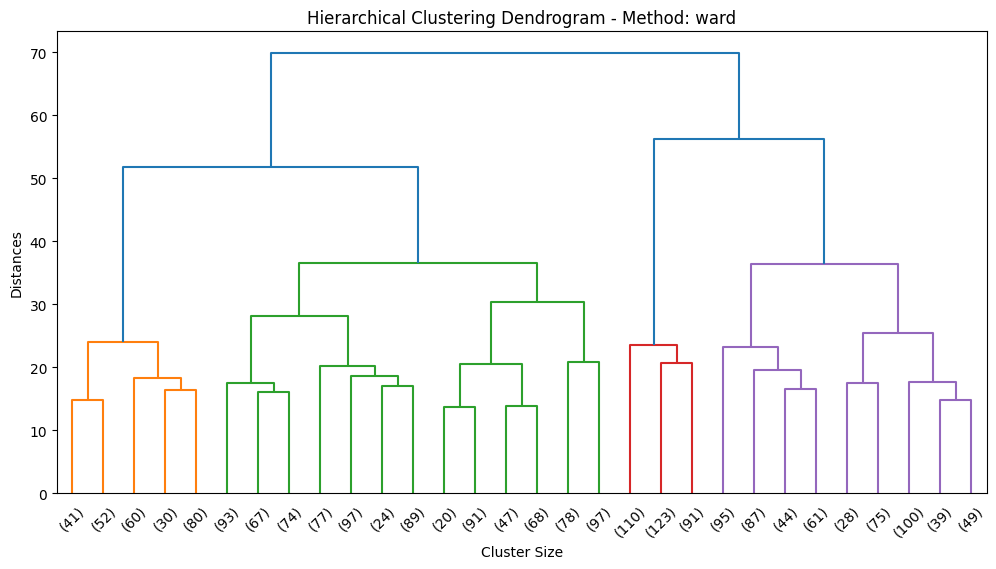

In [ ]:
methods = ["single", "complete", "average","ward"]
for m in methods:
    plt.figure(figsize=(12, 6))

    dendrogram = sch.dendrogram(sch.linkage(df_scaled, method=m), truncate_mode='lastp', p=30)

    plt.title(f"Hierarchical Clustering Dendrogram - Method: {m}")
    plt.xlabel("Cluster Size")
    plt.ylabel('Distances')
    plt.show()

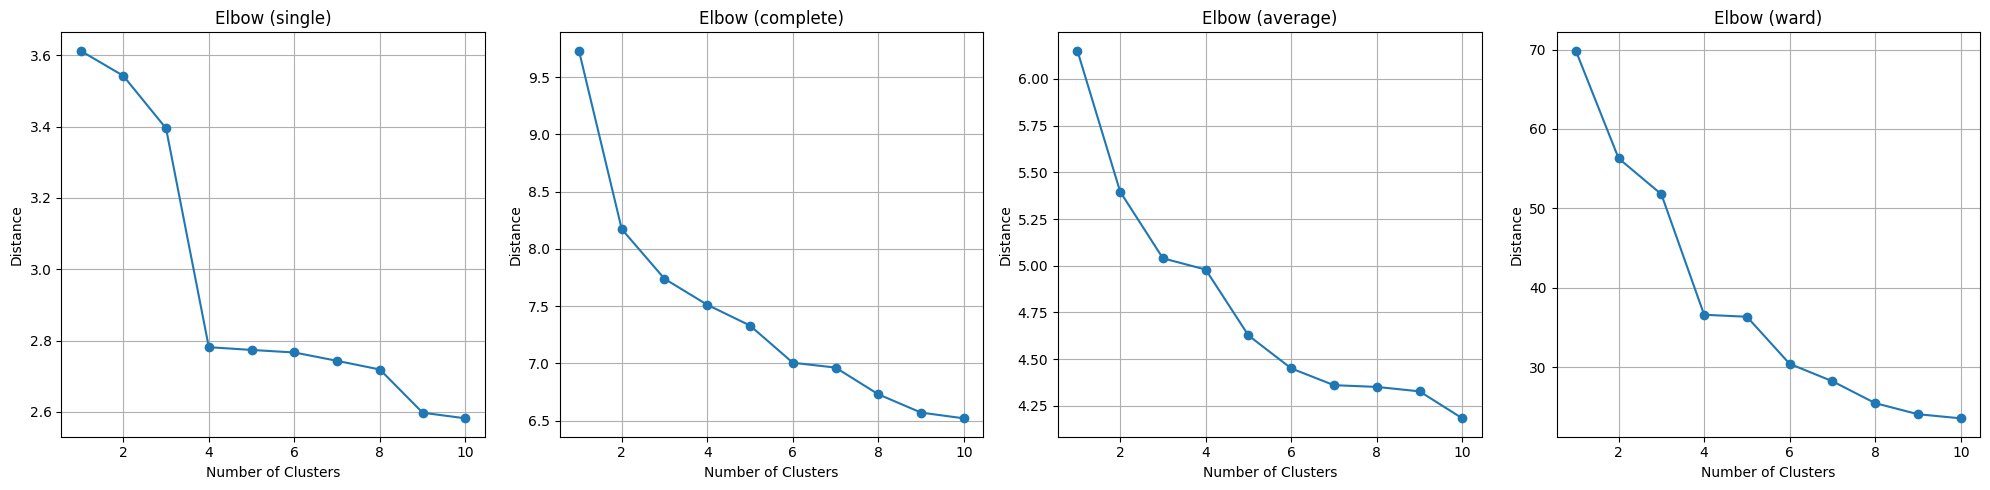

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.cluster.hierarchy as sch

df_hier = df_scaled.copy()
bool_cols = df_hier.select_dtypes(include=['bool']).columns
df_hier[bool_cols] = df_hier[bool_cols].astype(int)

methods = ["single", "complete", "average", "ward"]

plt.figure(figsize=(20, 5))

for i, m in enumerate(methods):
    Z = sch.linkage(df_hier, method=m)

    last_distances = Z[-10:, 2]
    last_distances_rev = last_distances[::-1]
    idxs = np.arange(1, len(last_distances_rev) + 1)

    plt.subplot(1, 4, i+1)
    plt.plot(idxs, last_distances_rev, marker='o')
    plt.title(f'Elbow ({m})')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Distance')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
k_range = range(2, 11)
results = []
for m in methods:
    for k in k_range:
        clusterer = AgglomerativeClustering(n_clusters=k, linkage=m)
        labels = clusterer.fit_predict(df_scaled)

        #Silhouette Score
        score = silhouette_score(df_scaled, labels)

        results.append({'Method': m, 'k': k, 'Silhouette': score})


results_df = pd.DataFrame(results)
pivot_results = results_df.pivot(index='k', columns='Method', values='Silhouette')
print("Silhouette Scores for each Linkage Method")
print(pivot_results.round(4))
best_row = results_df.loc[results_df['Silhouette'].idxmax()]
print(best_row)

Silhouette Scores for each Linkage Method
Method  average  complete  single    ward
k                                        
2        0.3167    0.0999  0.3849  0.1297
3        0.1928    0.0772  0.3235  0.1321
4        0.1163    0.0967  0.3239  0.1546
5        0.0684    0.0745  0.2086  0.1420
6        0.0685    0.0937  0.1115  0.1421
7        0.0793    0.0920  0.0634  0.1400
8        0.0552    0.0916  0.0384  0.1374
9        0.0533    0.0860  0.0227  0.1340
10       0.0400    0.0849  0.0026  0.1376
Method          single
k                    2
Silhouette    0.384861
Name: 0, dtype: object


In [ ]:
hc_complete = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_complete = hc_complete.fit_predict(df_scaled)

print("ward Linkage Sizes:")
print(pd.Series(labels_complete).value_counts().sort_index())

ward Linkage Sizes:
0    922
1    578
2    324
3    263
Name: count, dtype: int64


In [ ]:
df['HC_Cluster'] = labels_complete
df.groupby('HC_Cluster').mean()

,Age,FCVC,NCP,CH2O,FAF,TUE,BMI,Gender_Male,CALC_Sometimes,CALC_no,...,MTRANS_Public_Transportation,MTRANS_Walking,NObeyesdad_Normal_Weight,NObeyesdad_Obesity_Type_I,NObeyesdad_Obesity_Type_II,NObeyesdad_Obesity_Type_III,NObeyesdad_Overweight_Level_I,NObeyesdad_Overweight_Level_II,unhealthy_eating_habits,KMedoids_Cluster
HC_Cluster,,,,,,,,,,,,,,,,,,,,,
0,20.749917,2.291864,3.067908,2.023152,1.221861,0.799588,24.495262,0.582430,0.561822,0.396963,...,0.830803,0.040130,0.234273,0.202820,0.001085,0.0,0.157267,0.152928,0.877440,2.147505
1,31.782067,2.370431,2.640859,1.887255,0.980348,0.432331,32.754478,0.738754,0.673010,0.283737,...,0.397924,0.015571,0.029412,0.155709,0.512111,0.0,0.110727,0.186851,0.955017,1.453287
2,23.495554,3.000000,3.000000,2.208493,0.664817,0.604623,42.273746,0.003086,0.996914,0.003086,...,0.996914,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.996914,0.000000
3,21.714375,2.275256,1.179972,1.947454,0.780001,0.763307,26.265112,0.330798,0.570342,0.399240,...,0.908745,0.034221,0.186312,0.281369,0.000000,0.0,0.254753,0.155894,0.897338,2.171103


In [ ]:
analysis_cols = ['Age', 'BMI', 'FAF', 'FCVC']
hc_summary = df.groupby('HC_Cluster')[analysis_cols].mean()
hc_summary

,Age,BMI,FAF,FCVC
HC_Cluster,,,,
0,20.749917,24.495262,1.221861,2.291864
1,31.782067,32.754478,0.980348,2.370431
2,23.495554,42.273746,0.664817,3.000000
3,21.714375,26.265112,0.780001,2.275256


### **Hierarchical Clustering Analysis**
By analyzing the mean values for each cluster, we can categorize the participants into four distinct health and lifestyle profiles:
1. **Cluster 0:**

Clinical Status: Normal Weight

Behavioral Insight:
This group represents young individuals (Age ~20.7) with a healthy BMI (~24.5). They have the highest physical activity (FAF ~1.22), which plays a key role in maintaining their weight. Their lifestyle is relatively balanced, making them the healthiest group overall.

2. **Cluster 1:**

Clinical Status: Obese (Class I)

Behavioral Insight:
This is the oldest group (Age ~31.7) with a high BMI (~32.7). Their physical activity is lower, indicating a sedentary lifestyle. Weight gain here appears to be driven by age, reduced movement, and lifestyle habits, placing them at high health risk.

3. **Cluster 2:**

Clinical Status: Obese (Class III)

Behavioral Insight:
This group has the highest BMI (~42.2), indicating severe obesity. Interestingly, they show the highest vegetable intake (FCVC ~3.0), suggesting awareness and attempts to improve diet. However, their very low physical activity (FAF ~0.66) makes diet alone insufficient to manage their condition.

4.** Cluster 3:**

Clinical Status: Overweight

Behavioral Insight:
This group consists of young individuals (Age ~21.7) with BMI (~26.2). Their physical activity is relatively low, which puts them at moderate risk. While not obese, their current habits could lead to future weight gain if not improved.

## Overview — Fuzzy Logic

We use a Fuzzy Inference System to estimate the health risk of each individual based on BMI, physical activity frequency (FAF), and their assigned cluster. Fuzzy Logic handles uncertainty gracefully — a BMI of 26 isn't strictly "overweight," it's partially overweight and partially normal, and the system reflects that nuance in its output.



## **Fuzzy Logic**

In [ ]:
!pip install scikit-fuzzy

Installs the `scikit-fuzzy` library, which provides tools for building fuzzy membership functions and inference systems in Python.


In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

Imports the fuzzy logic components: `numpy` for numerical operations, `skfuzzy` for membership functions, and `ctrl` for defining antecedents, consequents, rules, and running simulations.


In [ ]:
df['BMI'].describe()

count    2087.000000
mean       29.765758
std         8.024934
min        12.998685
25%        24.368897
50%        28.896224
75%        36.095538
max        50.811753
Name: BMI, dtype: float64

Prints descriptive statistics for `BMI` to understand its actual range in the data, which informs the boundaries we set for the fuzzy membership functions.


In [ ]:
df['FAF'].describe()

count    2087.000000
mean        1.012812
std         0.853475
min         0.000000
25%         0.124505
50%         1.000000
75%         1.678102
max         3.000000
Name: FAF, dtype: float64

Same as above for `FAF` — checking the real min/max range before defining the fuzzy sets, so the universe of discourse covers all observed values.


In [ ]:
# Inputs
bmi = ctrl.Antecedent(np.arange(12, 51, 1), 'bmi')
faf = ctrl.Antecedent(np.arange(0, 3.1, 0.1), 'faf')
cluster = ctrl.Antecedent(np.arange(0, 4, 1), 'cluster')

# Output
health_risk= ctrl.Consequent(np.arange(0, 101, 1), 'health_risk')

Defines three input variables (Antecedents): BMI, FAF, and cluster — and one output variable (Consequent): `health_risk`. Each variable has a universe of discourse defined by `np.arange` over its valid range.


c:\Users\Tegwa\AppData\Local\Programs\Python\Python39\lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


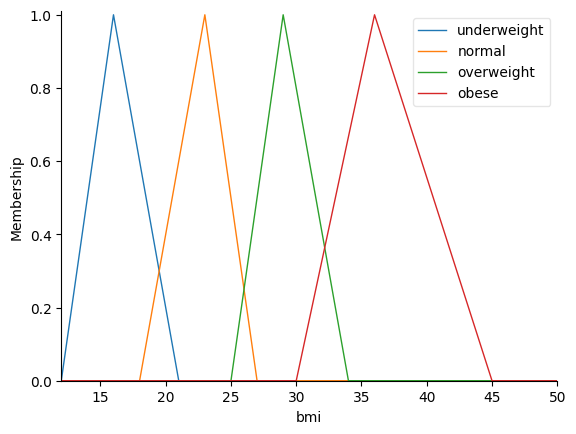

In [ ]:
bmi['underweight'] = fuzz.trimf(bmi.universe, [12, 16, 21])
bmi['normal'] = fuzz.trimf(bmi.universe, [18, 23, 27])
bmi['overweight'] = fuzz.trimf(bmi.universe, [25, 29, 34])
bmi['obese'] = fuzz.trimf(bmi.universe, [30, 36, 45])
bmi.view()

Defines four fuzzy sets for BMI (underweight, normal, overweight, obese) using triangular membership functions (`trimf`). Each function is defined by three points: [start, peak, end]. `bmi.view()` plots the resulting membership curves.


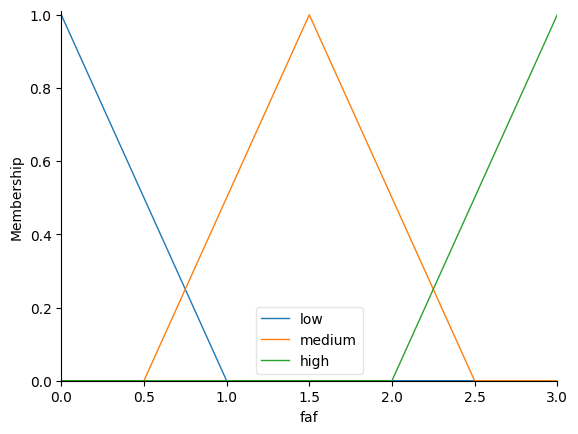

In [ ]:
faf['low'] = fuzz.trimf(faf.universe, [0, 0, 1])
faf['medium'] = fuzz.trimf(faf.universe, [0.5, 1.5, 2.5])
faf['high'] = fuzz.trimf(faf.universe, [2, 3, 3])
faf.view()

Defines three fuzzy sets for FAF (low, medium, high) using the same triangular approach. The overlapping regions between sets allow partial membership — a FAF of 1.5 is both somewhat "low" and somewhat "medium."


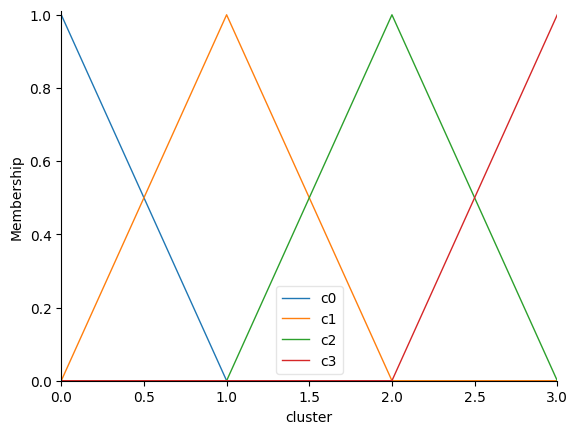

In [ ]:
cluster['c0'] = fuzz.trimf(cluster.universe, [0, 0, 1])
cluster['c1'] = fuzz.trimf(cluster.universe, [0, 1, 2])
cluster['c2'] = fuzz.trimf(cluster.universe, [1, 2, 3])
cluster['c3'] = fuzz.trimf(cluster.universe, [2, 3, 3])
cluster.view()

Defines fuzzy sets for the cluster input (c0 through c3), mapping each integer cluster label to a triangular membership function centered at its value. This allows the cluster assignment to feed naturally into the fuzzy rules.


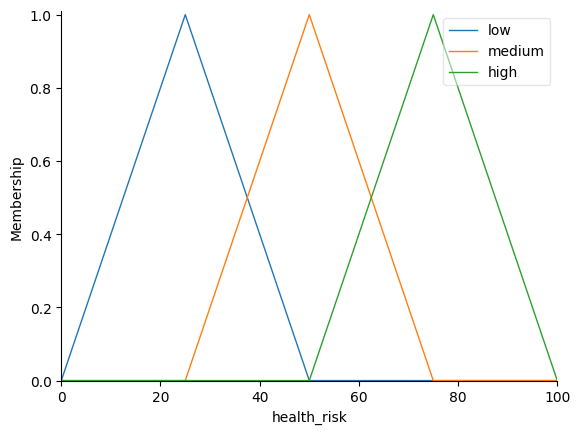

In [ ]:
health_risk['low'] = fuzz.trimf(health_risk.universe, [0, 25, 50])
health_risk['medium'] = fuzz.trimf(health_risk.universe, [25, 50, 75])
health_risk['high'] = fuzz.trimf(health_risk.universe, [50, 75, 100])
health_risk.view()

Defines three fuzzy output sets for `health_risk` (low, medium, high) over a 0–100 scale. The overlapping triangles ensure smooth, gradual transitions in the risk score rather than hard cutoffs.


In [ ]:
rules = [
    # --- Cluster 0: Obese Class III (High BMI but trying to eat healthy) ---
    # High BMI keeps them at High risk unless they exercise a lot
    ctrl.Rule(bmi['obese'] & faf['low'] & cluster['c0'], health_risk['high']),
    ctrl.Rule(bmi['obese'] & faf['medium'] & cluster['c0'], health_risk['high']),
    ctrl.Rule(bmi['obese'] & faf['high'] & cluster['c0'], health_risk['medium']), # Exercise helps
    ctrl.Rule(bmi['overweight'] & faf['low'] & cluster['c0'], health_risk['high']),
    ctrl.Rule(bmi['overweight'] & faf['medium'] & cluster['c0'], health_risk['medium']),
    ctrl.Rule(bmi['overweight'] & faf['high'] & cluster['c0'], health_risk['medium']),
    ctrl.Rule(bmi['normal'] & faf['low'] & cluster['c0'], health_risk['medium']),
    ctrl.Rule(bmi['normal'] & faf['medium'] & cluster['c0'], health_risk['low']),
    ctrl.Rule(bmi['normal'] & faf['high'] & cluster['c0'], health_risk['low']),
    ctrl.Rule(bmi['underweight'] & faf['low'] & cluster['c0'], health_risk['medium']),
    ctrl.Rule(bmi['underweight'] & faf['medium'] & cluster['c0'], health_risk['low']),
    ctrl.Rule(bmi['underweight'] & faf['high'] & cluster['c0'], health_risk['low']),

    # --- Cluster 1: Obese Class I (Lifestyle-driven, Older age) ---
    # Metabolism is slower, so risk is stickier
    ctrl.Rule(bmi['obese'] & faf['low'] & cluster['c1'], health_risk['high']),
    ctrl.Rule(bmi['obese'] & faf['medium'] & cluster['c1'], health_risk['high']),
    ctrl.Rule(bmi['obese'] & faf['high'] & cluster['c1'], health_risk['high']), # Harder to recover
    ctrl.Rule(bmi['overweight'] & faf['low'] & cluster['c1'], health_risk['high']),
    ctrl.Rule(bmi['overweight'] & faf['medium'] & cluster['c1'], health_risk['high']),
    ctrl.Rule(bmi['overweight'] & faf['high'] & cluster['c1'], health_risk['medium']),
    ctrl.Rule(bmi['normal'] & faf['low'] & cluster['c1'], health_risk['medium']),
    ctrl.Rule(bmi['normal'] & faf['medium'] & cluster['c1'], health_risk['medium']),
    ctrl.Rule(bmi['normal'] & faf['high'] & cluster['c1'], health_risk['low']),
    ctrl.Rule(bmi['underweight'] & faf['low'] & cluster['c1'], health_risk['medium']),
    ctrl.Rule(bmi['underweight'] & faf['medium'] & cluster['c1'], health_risk['low']),
    ctrl.Rule(bmi['underweight'] & faf['high'] & cluster['c1'], health_risk['low']),

    # --- Cluster 2: Overweight (Balanced lifestyle, Active) ---
    ctrl.Rule(bmi['obese'] & faf['low'] & cluster['c2'], health_risk['high']),
    ctrl.Rule(bmi['obese'] & faf['medium'] & cluster['c2'], health_risk['medium']),
    ctrl.Rule(bmi['obese'] & faf['high'] & cluster['c2'], health_risk['medium']),
    ctrl.Rule(bmi['overweight'] & faf['low'] & cluster['c2'], health_risk['medium']),
    ctrl.Rule(bmi['overweight'] & faf['medium'] & cluster['c2'], health_risk['low']),
    ctrl.Rule(bmi['overweight'] & faf['high'] & cluster['c2'], health_risk['low']),
    ctrl.Rule(bmi['normal'] & faf['low'] & cluster['c2'], health_risk['low']),
    ctrl.Rule(bmi['normal'] & faf['medium'] & cluster['c2'], health_risk['low']),
    ctrl.Rule(bmi['normal'] & faf['high'] & cluster['c2'], health_risk['low']),
    ctrl.Rule(bmi['underweight'] & faf['low'] & cluster['c2'], health_risk['low']),
    ctrl.Rule(bmi['underweight'] & faf['medium'] & cluster['c2'], health_risk['low']),
    ctrl.Rule(bmi['underweight'] & faf['high'] & cluster['c2'], health_risk['low']),

    # --- Cluster 3: Normal Weight (Clinically At-Risk, Poor habits) ---
    ctrl.Rule(bmi['obese'] & faf['low'] & cluster['c3'], health_risk['high']),
    ctrl.Rule(bmi['obese'] & faf['medium'] & cluster['c3'], health_risk['high']),
    ctrl.Rule(bmi['obese'] & faf['high'] & cluster['c3'], health_risk['high']),
    ctrl.Rule(bmi['overweight'] & faf['low'] & cluster['c3'], health_risk['high']),
    ctrl.Rule(bmi['overweight'] & faf['medium'] & cluster['c3'], health_risk['high']),
    ctrl.Rule(bmi['overweight'] & faf['high'] & cluster['c3'], health_risk['medium']),
    ctrl.Rule(bmi['normal'] & faf['low'] & cluster['c3'], health_risk['medium']), # Danger!
    ctrl.Rule(bmi['normal'] & faf['medium'] & cluster['c3'], health_risk['medium']),
    ctrl.Rule(bmi['normal'] & faf['high'] & cluster['c3'], health_risk['medium']), # Still risky
    ctrl.Rule(bmi['underweight'] & faf['low'] & cluster['c3'], health_risk['medium']),
    ctrl.Rule(bmi['underweight'] & faf['medium'] & cluster['c3'], health_risk['medium']),
    ctrl.Rule(bmi['underweight'] & faf['high'] & cluster['c3'], health_risk['medium']),
]

Defines all fuzzy inference rules. Each rule specifies: IF BMI is [X] AND FAF is [Y] AND cluster is [Z] THEN health_risk is [W]. Rules are tailored per cluster — for example, Cluster 1 (older, sedentary individuals) has stricter rules because their metabolic recovery is slower.


In [ ]:
system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)

Assembles all rules into a `ControlSystem` and wraps it in a `ControlSystemSimulation` object, which is the engine used to compute outputs for any given set of input values.


Row 1100: Health Risk = 24.999999999999993


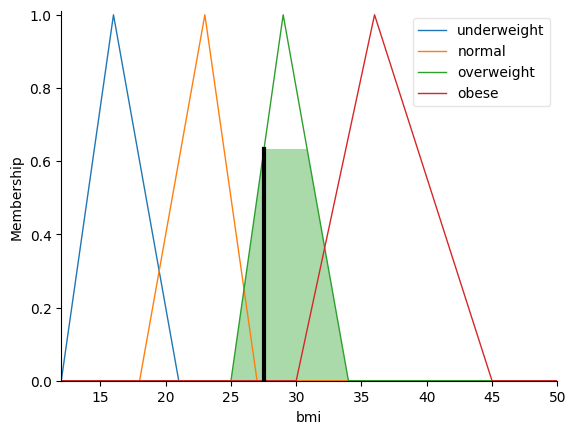

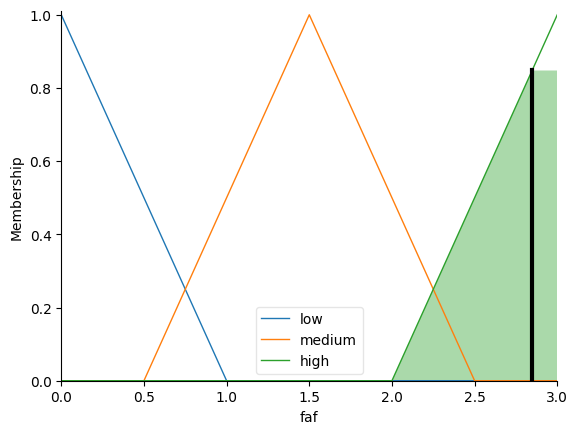

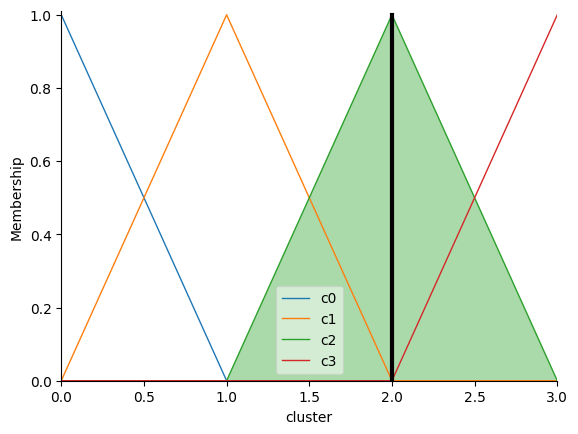

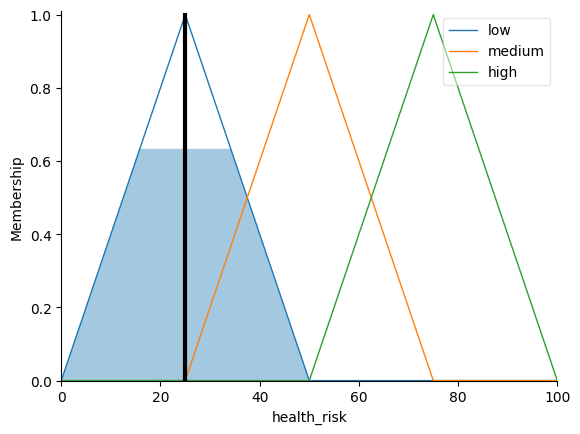

In [ ]:
for i in range(1100,1101):
    sim = ctrl.ControlSystemSimulation(system)

    row = df.iloc[i]

    sim.input['bmi'] = row['BMI']
    sim.input['faf'] = row['FAF']
    sim.input['cluster'] = int(row['KMedoids_Cluster'])

    sim.compute()

    if 'health_risk' in sim.output:
        print(f"Row {i}: Health Risk = {sim.output['health_risk']}")
        bmi.view(sim)
        faf.view(sim)
        cluster.view(sim)
        health_risk.view(sim)
    else:
        print(f"Row {i}: NO OUTPUT")

Tests the fuzzy system on a single row (index 1100). BMI, FAF, and cluster are passed as inputs, `sim.compute()` runs the inference, and the resulting health risk score is printed along with visual plots of each membership function's activation state.


## Overview — Genetic Algorithm (Feature Selection)

We apply a Genetic Algorithm to identify the most informative subset of features for clustering. Inspired by natural selection, the algorithm evolves a population of candidate feature sets over multiple generations, retaining and recombining the best-performing ones. The fitness metric is the Silhouette Score from KMedoids clustering.



## **Genetic:(Feature Selection)**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

Suppresses non-critical warnings to keep the output clean during the genetic algorithm's iterative runs.


In [ ]:
n_features = df_scaled.shape[1]

Stores the total number of features in `df_scaled` as `n_features`. This determines the length of each chromosome — a binary vector where 1 means "include this feature" and 0 means "exclude it."


In [ ]:
import numpy as np

def create_individual():
    return np.random.randint(0, 2, n_features)

`create_individual()` generates a random chromosome: a binary array of length `n_features`. Each element is independently drawn from {0, 1}, representing one possible feature subset — a single candidate solution.


In [ ]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

def fitness(individual):

    selected = df_scaled.iloc[:, individual == 1]
    if selected.shape[1] == 0:
        return 0

    try:
        model = KMedoids(n_clusters=4, random_state=42)
        labels = model.fit_predict(selected)

        return silhouette_score(selected, labels)

    except:
        return 0

`fitness()` evaluates a chromosome by selecting the features it encodes, running KMedoids with k=4, and returning the resulting Silhouette Score. Higher scores mean the selected features produce better-separated clusters. Returns 0 if no features are selected or clustering fails.


In [ ]:
import random

def select_parent(population):
    tournament = random.sample(population, 3)
    return max(tournament, key=fitness)

`select_parent()` implements tournament selection: it randomly samples 3 chromosomes from the population and returns the one with the highest fitness. This gives better solutions a higher probability of being chosen as parents without excluding weaker ones entirely.


In [ ]:
def crossover(p1, p2):
    point = random.randint(1, n_features - 1)
    return np.concatenate([p1[:point], p2[point:]])


`crossover()` combines two parent chromosomes at a random split point to produce a child. The child inherits the first segment from parent 1 and the second from parent 2, simulating genetic recombination.


In [ ]:
mutation_rate = 0.2

def mutate(individual):
    for i in range(len(individual)):
        if random.random() < mutation_rate:
            individual[i] = 1 - individual[i]
    return individual

`mutate()` introduces random variation: each bit in the chromosome has a 20% chance of flipping. This prevents the population from converging prematurely and ensures the search space is explored broadly.


In [ ]:
population_size = 30
generations = 20

def genetic_algorithm():

    population = [create_individual() for _ in range(population_size)]
    best_per_gen = []

    for gen in range(generations):
        population = sorted(population, key=fitness, reverse=True)
        best_score = fitness(population[0])
        best_per_gen.append(best_score)

        print(f"Generation {gen+1}: Best Fitness = {fitness(population[0])}")

        new_population = []

        for _ in range(population_size):
            p1 = select_parent(population)
            p2 = select_parent(population)

            child = crossover(p1, p2)
            child = mutate(child)

            new_population.append(child)

        population = new_population

    best = max(population, key=fitness)
    return best, best_per_gen

`genetic_algorithm()` is the main loop. It initializes a population of 30 random chromosomes and evolves it over 20 generations. Each generation: sorts by fitness, logs the best score, then builds a new population through selection, crossover, and mutation. Returns the best chromosome found.


In [ ]:
import warnings
warnings.filterwarnings('ignore')

Re-suppresses warnings immediately before running the genetic algorithm to ensure its printed output (generation-by-generation fitness scores) is not cluttered with library warnings.


In [ ]:
best, best_per_gen = genetic_algorithm()

print("Best Chromosome:", best)
print("Selected Components:", np.where(best == 1)[0])

Generation 1: Best Fitness = 0.46485144071147266
Generation 2: Best Fitness = 0.4919661060807144
Generation 3: Best Fitness = 0.44067482293907473
Generation 4: Best Fitness = 0.36007048166706357
Generation 5: Best Fitness = 0.36284934315912465
Generation 6: Best Fitness = 0.33274894551640105
Generation 7: Best Fitness = 0.3173900616666883
Generation 8: Best Fitness = 0.35972512863988965
Generation 9: Best Fitness = 0.4086721485707133
Generation 10: Best Fitness = 0.364389992470464
Generation 11: Best Fitness = 0.43265662496525475
Generation 12: Best Fitness = 0.3632587289971356
Generation 13: Best Fitness = 0.404719171965386
Generation 14: Best Fitness = 0.33444378544575615
Generation 15: Best Fitness = 0.3352590400170303
Generation 16: Best Fitness = 0.3543108725579355
Generation 17: Best Fitness = 0.4139518229700365
Generation 18: Best Fitness = 0.32404444550509653
Generation 19: Best Fitness = 0.36411481355926556
Generation 20: Best Fitness = 0.4396004241148812
Best Chromosome: [0 1

Runs the genetic algorithm and prints the best chromosome (binary vector) along with the indices of the selected features. This is the feature subset that maximized clustering quality across all generations.


In [ ]:
print(df[[1,2,8,10,18,21,24,25]])

Prints the actual data values for the columns at the indices selected by the genetic algorithm. Used to inspect the content of the chosen features before evaluating clustering performance.


In [47]:
model = KMedoids(n_clusters=4, random_state=42)
labels = model.fit_predict(df_scaled)

baseline = silhouette_score(df_scaled, labels)
print("Baseline:", baseline)

Baseline: 0.11631369240212172


Computes a baseline Silhouette Score using all features with KMedoids (k=6). This serves as the reference point for comparing whether the genetic algorithm's feature selection actually improves clustering.


In [ ]:
X_selected = df_scaled.iloc[:, best == 1]

model = KMedoids(n_clusters=4, random_state=42)
labels = model.fit_predict(X_selected)

ga_score = silhouette_score(X_selected, labels)
print("After GA:", ga_score)

After GA: 0.40862402332084374


Runs KMedoids using only the features selected by the genetic algorithm and computes the resulting Silhouette Score. Comparing this to the baseline quantifies the benefit of feature selection.


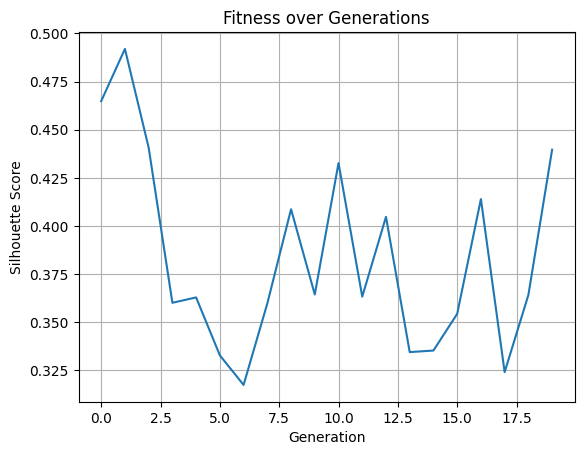

In [ ]:
import matplotlib.pyplot as plt

plt.plot(best_per_gen)
plt.title("Fitness over Generations")
plt.xlabel("Generation")
plt.ylabel("Silhouette Score")
plt.grid()
plt.show()

Plots the best fitness score per generation as a line chart. An upward trend confirms the genetic algorithm is making meaningful progress across generations rather than searching randomly.


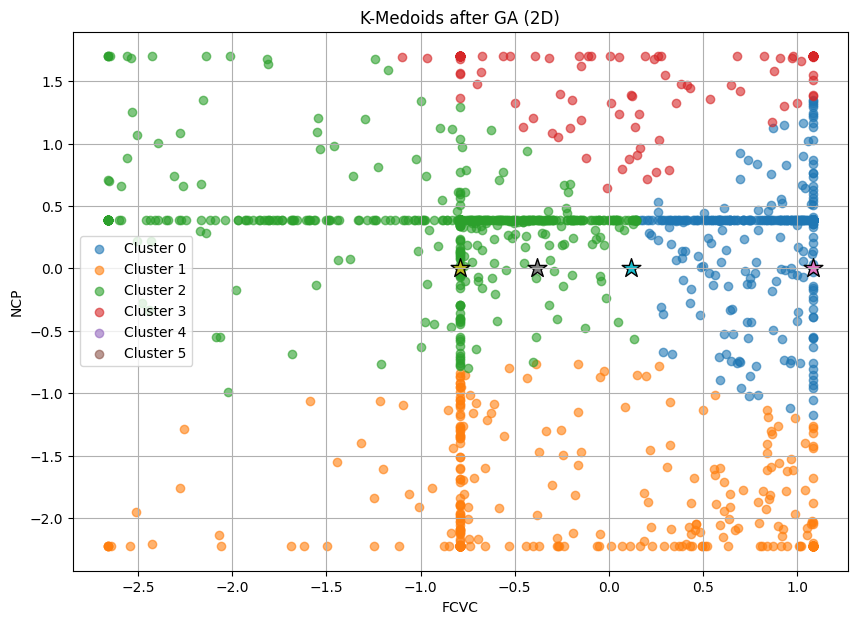

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
cols = ['Age','FAF', 'BMI']
for j in range(6):
    mask = labels == j
    plt.scatter(
        X_selected.iloc[mask, 0],
        X_selected.iloc[mask, 1],
        label=f'Cluster {j}',
        alpha=0.6
    )
medoids = model.medoid_indices_

for j in range(4):
    mx = X_selected.iloc[medoids[j], 0]
    my = X_selected.iloc[medoids[j], 6]
    plt.scatter(mx, my, s=200, marker='*', edgecolors='black')

plt.title('K-Medoids after GA (2D)')
plt.xlabel(X_selected.columns[0])
plt.ylabel(X_selected.columns[1])
plt.legend()
plt.grid()
plt.show()

Plots a 2D scatter of the clusters produced by KMedoids after feature selection. Each color represents a different cluster, and star markers indicate the medoid (most centrally representative point) of each cluster.


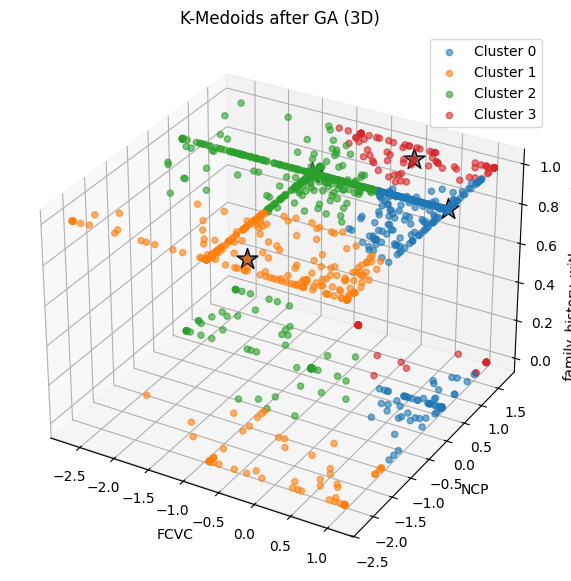

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
cols = ['Age','FAF', 'BMI']
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for j in range(4):
    mask = labels == j
    ax.scatter(
        X_selected.iloc[mask, 0],
        X_selected.iloc[mask, 1],
        X_selected.iloc[mask, 2],
        label=f'Cluster {j}',
        alpha=0.6
    )

for j in range(4):
    mx = X_selected.iloc[medoids[j], 0]
    my = X_selected.iloc[medoids[j], 1]
    mz = X_selected.iloc[medoids[j], 2]
    ax.scatter(mx, my, mz, s=250, marker='*', edgecolors='black')

ax.set_title('K-Medoids after GA (3D)')
ax.set_xlabel(X_selected.columns[0])
ax.set_ylabel(X_selected.columns[1])
ax.set_zlabel(X_selected.columns[2])
ax.legend()

plt.show()

Renders the same clustering result in 3D using Age, FAF, and BMI as axes. The 3D view gives a richer spatial sense of how the clusters are separated across multiple dimensions simultaneously.


In [ ]:
X_train_columns = [col for col in X_train_columns if col not in ['KMedoids_Cluster', 'HC_Cluster']]
print(len(X_train_columns))

26


Cleans up `X_train_columns` by removing the cluster label columns (`KMedoids_Cluster`, `HC_Cluster`) that were added during analysis. These should not be treated as input features during prediction.


In [ ]:
import json
def evaluate_health_risk_real(record_index, df_clean, scaler, model, X_train_columns):
    record = df_clean.iloc[[record_index]].copy()

    bmi_val = float(record['BMI'].iloc[0])
    faf_val = float(record['FAF'].iloc[0])

    record_encoded = pd.get_dummies(record)
    favc = record_encoded.get('FAVC_yes', pd.Series([0])).astype(int)
    caec = record_encoded.get('CAEC_Frequently', pd.Series([0])).astype(int)
    calc = record_encoded.get('CALC_Frequently', pd.Series([0])).astype(int)

    record_encoded['unhealthy_eating_habits'] = favc | caec | calc
    cols_to_drop = [col for col in ['FAVC_yes', 'CAEC_Frequently', 'CALC_Frequently'] if col in record_encoded.columns]
    record_encoded.drop(columns=cols_to_drop, inplace=True)
    record_final = record_encoded.reindex(columns=X_train_columns, fill_value=0)
    record_final = record_final.fillna(0)

    num_cols = ['Age', 'BMI', 'NCP', 'TUE', 'CH2O', 'FCVC', 'FAF']
    record_final[num_cols] = scaler.transform(record_final[num_cols])
    predicted_cluster = model.predict(record_final)[0]

    sim.input['bmi'] = bmi_val
    sim.input['faf'] = faf_val
    sim.input['cluster'] = predicted_cluster
    sim.compute()
    risk_score = sim.output['health_risk']

    if risk_score < 35: status = 'Low Risk'
    elif risk_score < 65: status = 'Moderate Risk'
    else: status = 'High Risk'

    report = {'BMI': bmi_val,
        'Physical Activity (FAF)':faf_val,
        'Predicted Cluster': int(predicted_cluster),
        'Fuzzy Risk Score': round(risk_score, 2),
        'Final Assessment: you have ': status
    }
    return report

Defines `evaluate_health_risk_real()`, the full end-to-end inference pipeline. Given a record index, it: retrieves the raw record, applies encoding and feature engineering, aligns columns to the training schema, scales numeric features, predicts the cluster via KMedoids, runs the fuzzy inference system, and returns a structured health risk report.


In [ ]:
patient_report = evaluate_health_risk_real(500, df_cleaned, scaler, model, X_train_columns)
print(json.dumps(patient_report, indent=4))

{
    "BMI": 18.223023517295385,
    "Physical Activity (FAF)": 1.978631,
    "Predicted Cluster": 2,
    "Fuzzy Risk Score": 25.0,
    "Final Assessment: you have ": "Low Risk"
}


C:\Users\Tegwa\AppData\Local\Temp\ipykernel_7096\2927045839.py:14: FutureWarning: Operation between Series with different indexes that are not of numpy boolean or object dtype will no longer return a numpy boolean result in a future version. Cast both Series to object type to maintain the prior behavior.
  record_encoded['unhealthy_eating_habits'] = favc | caec | calc


Runs the full pipeline on individual at index 500 and prints the resulting JSON report. The output includes BMI, FAF, predicted cluster, fuzzy risk score, and a final risk category (Low / Moderate / High).
